## 04_histogram

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("../data/checking-logs.sqlite")
cur = conn.cursor()

### анализируйте только пользователей, а не администраторов

In [2]:
checker = pd.read_sql(
    """
        SELECT timestamp
        FROM checker
        WHERE uid LIKE 'user_%' 
    """,
    conn,
    parse_dates="timestamp",
)
checker["date"] = checker.timestamp.dt.date
checker["hour"] = checker.timestamp.dt.hour
checker["type"] = checker.timestamp.dt.dayofweek.apply(
    lambda x: "working_day" if x < 5 else "weekend"
)
checker

,timestamp,date,hour,type
0,2020-04-17 05:19:02.744528,2020-04-17,5,working_day
1,2020-04-17 05:22:35.249331,2020-04-17,5,working_day
2,2020-04-17 05:22:45.549397,2020-04-17,5,working_day
3,2020-04-17 05:34:14.691200,2020-04-17,5,working_day
4,2020-04-17 05:34:24.422370,2020-04-17,5,working_day
...,...,...,...,...
3202,2020-05-21 20:19:06.872761,2020-05-21,20,working_day
3203,2020-05-21 20:22:41.785725,2020-05-21,20,working_day
3204,2020-05-21 20:22:41.877806,2020-05-21,20,working_day
3205,2020-05-21 20:37:00.129678,2020-05-21,20,working_day


### создайте два списка значений (для рабочих дней и для выходных) для ввода в гистограмму

In [3]:
working_day = checker[checker["type"] == "working_day"][["hour"]].reset_index(drop=True)
working_day

,hour
0,5
1,5
2,5
3,5
4,5
...,...
2032,20
2033,20
2034,20
2035,20


In [4]:
weekend = checker[checker["type"] == "weekend"][["hour"]].reset_index(drop=True)
weekend

,hour
0,7
1,13
2,13
3,13
4,13
...,...
1165,22
1166,22
1167,22
1168,22


### используйте уровень прозрачности для гистограммы спереди, равный 0,7

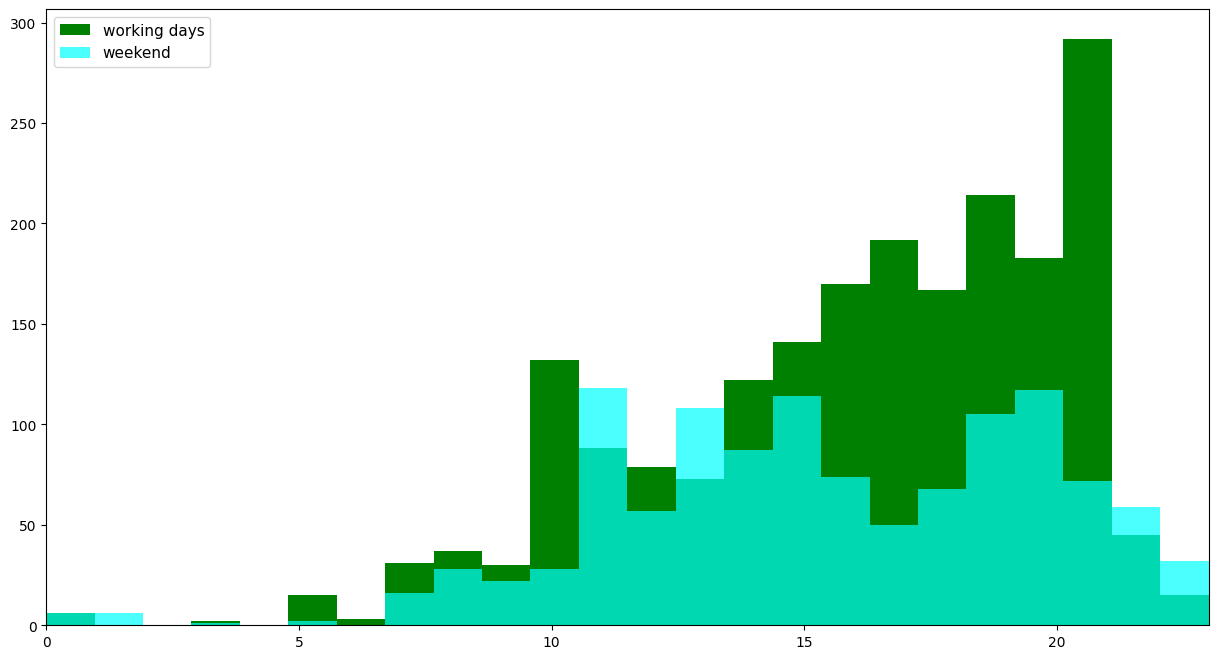

In [5]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.hist(working_day, bins=24, color="green")
ax.hist(weekend, bins=24, color="cyan", alpha=0.7)
ax.set_xlim(0, 23)
ax.legend(["working days", "weekend"], loc="upper left", fontsize="11")

### Бывают ли часы, когда общее количество коммитов в выходные дни выше, чем в рабочие? Ответ - 11, 13, 22, 23.

In [6]:
conn.close()